In [65]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm import tqdm

DATA_DIR = Path("../data/m5")
SUBMISSIONS_DIR = DATA_DIR / "uncertainty_submissions"
TR_VAL_PATH = DATA_DIR / "sales_train_validation.csv"
TR_EVAL_PATH = DATA_DIR / "sales_train_evaluation.csv"
CALENDAR_PATH = DATA_DIR / "calendar.csv"

## Preprocessing

In [134]:
eval_df_whole = pd.read_csv(TR_EVAL_PATH)

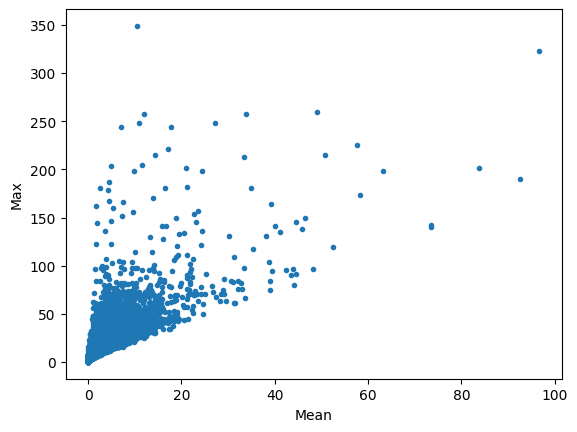

In [104]:
import matplotlib.pyplot as plt

plt.plot(eval_df_whole.loc[:, f'd_{1913-364}':f'd_{1913}'].mean(axis=1), eval_df_whole.loc[:, f'd_{1913-364}':f'd_{1913}'].max(axis=1), '.')
plt.xlabel('Mean')
plt.ylabel('Max')
plt.show()

In [178]:
# Read the sales_train_evaluation.csv file then only takes the parts we need
assert eval_df_whole.isna().sum().sum() == 0
last_year_sale_mean = eval_df_whole.loc[:, f'd_{1913-364}':f'd_{1913}'].mean(axis=1)
eval_df = eval_df_whole.loc[last_year_sale_mean > 0.142, ['id', 'd_1920', 'd_1927','d_1934']]
eval_df['mean'] = last_year_sale_mean.loc[eval_df.index]
eval_df['id'] = eval_df['id'].str[:-11]

ITEM_MAP = {id: f'X{i}' for i, id in enumerate(eval_df['id'].unique())} # 26719 items
ITEM_R_MAP = {v: k for k, v in ITEM_MAP.items()}

eval_df['id'] = eval_df['id'].map(ITEM_MAP)
eval_df.set_index('id', inplace=True)
eval_df.to_csv(DATA_DIR / 'small_eval_df.csv', index=True)

In [179]:
eval_df

,d_1920,d_1927,d_1934,mean
id,,,,
X0,5,1,0,0.679452
X1,0,0,2,0.353425
X2,1,3,2,0.534247
X3,6,4,0,1.964384
X4,3,3,0,1.128767
...,...,...,...,...
X26714,5,1,5,1.890411
X26715,0,1,3,0.580822
X26716,1,1,1,0.635616


In [180]:
sfiles = sorted(SUBMISSIONS_DIR.glob("*.csv"))

for n, sfile in enumerate(tqdm(sfiles)):
    df = pd.read_csv(sfile)
    df = df[df['id'].str.endswith('_validation')][['id', 'F7', 'F14', 'F21']].copy()  # corresponds to d_1920, 1927, 1934
    df['q_level'] = df['id'].str[-16:-11].astype(float)
    df['id'] = df['id'].str[:-17].map(ITEM_MAP)
    # drop rows with id NaN
    df = df[df['id'].notna()]
    df = df[['id', 'q_level', 'F7', 'F14', 'F21']].sort_values(by=['id', 'q_level'])
    # id is of X0 X1 X2 ... X26718, we want to sort it by X0 X1 X2 ... X26718

    df.to_csv(SUBMISSIONS_DIR / f'Forecast_{n}.csv', index=False)
    break

  0%|          | 0/100 [00:01<?, ?it/s]


In [182]:
eval_df = pd.read_csv(DATA_DIR / 'small_eval_df.csv', index_col='id')
last_year_sale_mean = eval_df['mean']
last_year_sale_mean

id
X0        0.679452
X1        0.353425
X2        0.534247
X3        1.964384
X4        1.128767
            ...   
X26714    1.890411
X26715    0.580822
X26716    0.635616
X26717    1.082192
X26718    1.723288
Name: mean, Length: 26719, dtype: float64

In [185]:
df_q

,q_level,F7,F14,F21
id,,,,
X0,0.005,0.0,0.0,0.0
X1,0.005,0.0,0.0,0.0
X10,0.005,0.0,0.0,0.0
X100,0.005,0.0,0.0,0.0
X1000,0.005,0.0,0.0,0.0
...,...,...,...,...
X9995,0.005,0.0,0.0,0.0
X9996,0.005,0.0,0.0,0.0
X9997,0.005,0.0,0.0,0.0


In [188]:
len(last_year_sale_mean.index)

26719

In [ ]:
q_level = [0.005, 0.025, 0.165, 0.25 , 0.5  , 0.75 , 0.835, 0.975, 0.995]
b_forecasts_d7 = {q: {} for q in q_level}
b_forecasts_d14 = {q: {} for q in q_level}
b_forecasts_d21 = {q: {} for q in q_level}

eval_df = pd.read_csv(DATA_DIR / 'small_eval_df.csv', index_col='id')
last_year_sale_mean = eval_df['mean']

for n in tqdm(range(50)):
    df = pd.read_csv(SUBMISSIONS_DIR / f'Forecast_{n}.csv')
    for q in q_level:
        df_q = df[df['q_level'] == q].set_index('id')
        if df_q.shape[0] != len(last_year_sale_mean) or set(last_year_sale_mean.index) != set(df_q.index):
            raise ValueError("Indices do not contain the same elements (unordered check failed)")
        b_forecasts_d7[q][f'F{n}'] = np.round(np.maximum(0, df_q['F7']) / last_year_sale_mean, 2)
        b_forecasts_d14[q][f'F{n}'] = np.round(np.maximum(0, df_q['F14']) / last_year_sale_mean, 2)
        b_forecasts_d21[q][f'F{n}'] = np.round(np.maximum(0, df_q['F21']) / last_year_sale_mean, 2)
    break

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


In [190]:
b_forecasts_d7

{0.005: {'F0': id
  X0       0.0
  X1       0.0
  X10      0.0
  X100     0.0
  X1000    0.0
          ... 
  X9995    0.0
  X9996    0.0
  X9997    0.0
  X9998    0.0
  X9999    0.0
  Length: 26719, dtype: float64},
 0.025: {'F0': id
  X0       0.0
  X1       0.0
  X10      0.0
  X100     0.0
  X1000    0.0
          ... 
  X9995    0.0
  X9996    0.0
  X9997    0.0
  X9998    0.0
  X9999    0.0
  Length: 26719, dtype: float64},
 0.165: {'F0': id
  X0       0.0
  X1       0.0
  X10      0.0
  X100     0.0
  X1000    0.0
          ... 
  X9995    0.0
  X9996    0.0
  X9997    0.0
  X9998    0.0
  X9999    0.0
  Length: 26719, dtype: float64},
 0.25: {'F0': id
  X0       0.00
  X1       0.00
  X10      0.00
  X100     0.00
  X1000    0.00
           ... 
  X9995    0.00
  X9996    0.00
  X9997    0.00
  X9998    0.00
  X9999    0.01
  Length: 26719, dtype: float64},
 0.5: {'F0': id
  X0       1.60
  X1       0.00
  X10      0.00
  X100     0.73
  X1000    0.01
           ... 
  X9995   

## Sanity check - only NA for now
negative, sorted (Should we?)

In [69]:
forecasts = np.array([SUBMISSIONS_DIR / f'Forecast_{n}.csv' for n in range(50)])
na_flag = False

for forecast in forecasts:
    df = pd.read_csv(forecast)
    if df.isna().sum().sum():
        print(forecast, df.isna().sum().sum())
        na_flag = True

if not na_flag:
    print("No NaNs in any forecast")

No NaNs in any forecast
